In [1]:
## loading the necessary libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

### PART A :
#### GOAL 1:1
- The data set created is a synthetic time series dataset with a panel structure were it tracks specifically three currencies over a period of one year at regular 24 hour intervals  for financial year 2023. The prices for the tickers are generated using a random walk where the data set exhibits a stochastic trend(long term drifts in time series with permanent effect on level of data)


In [14]:
start_date = '2023-01-01'
end_date = '2023-12-31'

tickers =['TECH','GOLD','RETL'] ##these are some of the different currencies on the stock market 

initial_prices = {'TECH':150,'GOLD':2000,'RETL':50}
volatiliy = {'TECH':0.02,'GOLD':0.01,'RETL':0.015}

dates = pd.date_range(start=start_date, end=end_date, freq='D')

dataset = []

for ticker in tickers:
    price = initial_prices[ticker]
    vol = volatiliy[ticker]
    prices = [price]

    for _ in range(len(dates) - 1):
        daily_return = np.random.normal(0.0005, vol)
        price *= (1 + daily_return)
        prices.append(price)
    
    dataFrame = pd.DataFrame({'Date':dates, 'Ticker':ticker, 'Close': prices})
    dataFrame['Open'] = dataFrame['Close'] * (1 + np.random.normal(0,0.002,len(dates)))
    dataFrame['High'] = dataFrame[['Open','Close']].max(axis=1) * (1 + abs(np.random.normal(0 , 0.003,len(dates))))
    dataFrame['Low'] = dataFrame[['Open','Close']].min(axis=1) * (1 - abs(np.random.normal(0 , 0.003,len(dates))))
    dataFrame['Volume'] = np.random.randint(100000,1000000,len(dates))

    dataset.append(dataFrame)

data = pd.concat(dataset).sort_values(['Date','Ticker']).reset_index(drop=True)
data.head()



,Date,Ticker,Close,Open,High,Low,Volume
0,2023-01-01,GOLD,2000.000000,2009.101818,2011.953078,1988.872435,527874
1,2023-01-01,RETL,50.000000,50.016157,50.197116,49.743256,290398
2,2023-01-01,TECH,150.000000,149.576723,150.113399,148.497434,156493
3,2023-01-02,GOLD,1998.570720,2000.432759,2000.800104,1997.120612,352661
4,2023-01-02,RETL,49.990138,50.070445,50.148625,49.866204,952656


In [19]:
##we are going to carry out a time series analysis on the price of GOLD  in 2023
gold_data = data[data['Ticker'] == 'GOLD'][['Date', 'Open', 'Close']].copy()

##setting the date as index for tsa 
gold_data.set_index('Date', inplace=True)
gold_data.head()

,Open,Close
Date,,
2023-01-01,2009.101818,2000.000000
2023-01-02,2000.432759,1998.570720
2023-01-03,1984.138850,1988.166310
2023-01-04,1967.440051,1966.679147
2023-01-05,1943.618837,1946.192449


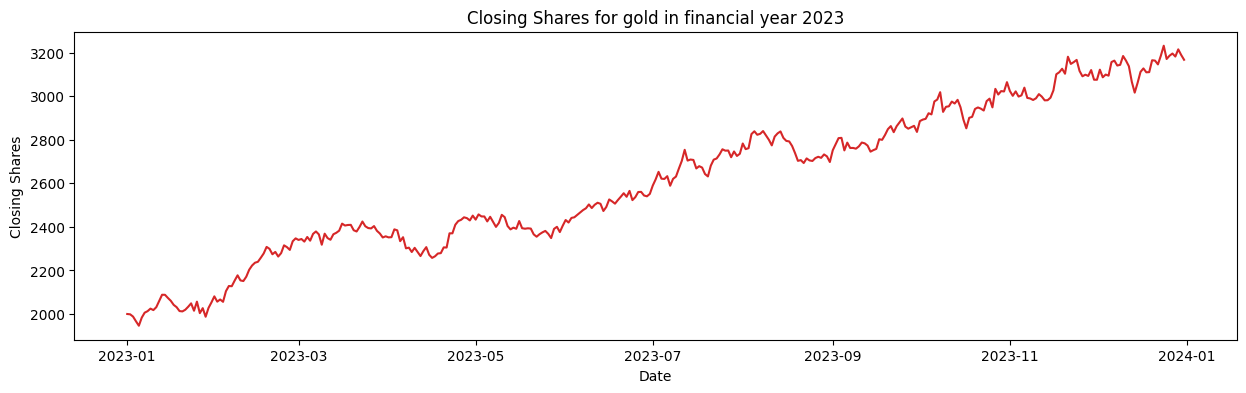

In [21]:
##creating a function to plot our data 
def plot_df(data, x, y, title="", xlabel='Date', ylabel='Closing Shares', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_df(gold_data, x=gold_data.index, y=gold_data['Close'], title='Closing Shares for gold in financial year 2023')

#### GOAL 1:2

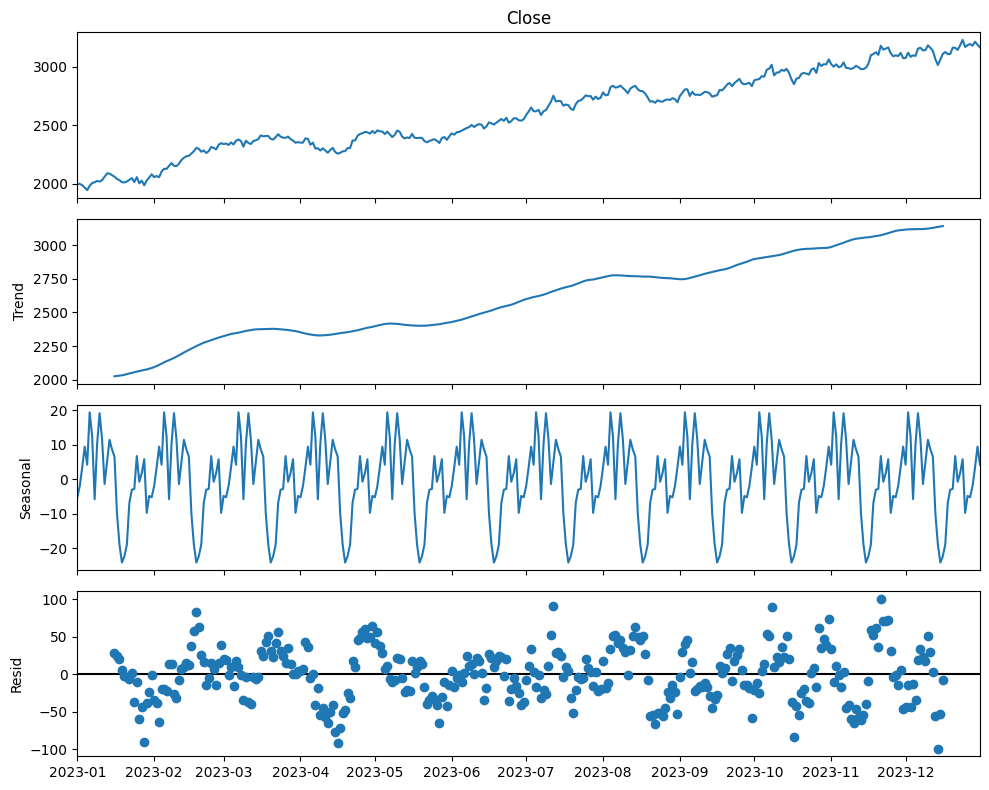

In [22]:
decomp = seasonal_decompose(gold_data['Close'],model='additive',period=30)

##visualising the decomposition 
fig = decomp.plot()
fig.set_size_inches(10,8)
plt.tight_layout()
plt.show()